In [64]:
import xarray as xr
from netCDF4 import Dataset

In [77]:
ds_norm = xr.open_zarr('/scratch3/NAGAPE/gpu-ai4wp/Zhanxiang.Hua/credit_wofs_da_example/wofs_da_increment_experiment_0505_ens/test2/test_samples_2021.zarr').sel(ensemble_member=6)
ds_denorm = xr.open_zarr('/scratch3/NAGAPE/gpu-ai4wp/Zhanxiang.Hua/credit_wofs_da_example/wofs_da_increment_experiment_0505_ens/test2/eval_physical.zarr')

In [79]:
ds_norm

<xarray.Dataset> Size: 16GB
Dimensions:           (sample: 64, boundary_channel: 17, time: 1, y: 300,
                       x: 300, input_channel: 267, output_channel: 136)
Coordinates:
  * sample            (sample) int64 512B 0 1 2 3 4 5 6 ... 57 58 59 60 61 62 63
    valid_time        (sample) datetime64[ns] 512B dask.array<chunksize=(8,), meta=np.ndarray>
  * boundary_channel  (boundary_channel) <U19 1kB 'REFL_10CM_L0_innov' ... 'R...
  * time              (time) int64 8B 0
  * y                 (y) int64 2kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * x                 (x) int64 2kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * input_channel     (input_channel) <U26 28kB 'QRAIN_L0_t0' ... 'HGT_dyn'
  * output_channel    (output_channel) <U13 7kB 'QRAIN_L0' ... 'QNSNOW_L16'
    ensemble_member   int64 8B 6
Data variables:
    case_name         (sample) |S128 8kB dask.array<chunksize=(8,), meta=np.ndarray>
    case_path         (sample) |S512 33kB dask.array<chunksize=(8,), meta=np.ndarray>
    global_index      (sample) int64 512B dask.array<chunksize=(8,), meta=np.ndarray>
    metric_acc        (sample) float32 256B dask.array<chunksize=(8,), meta=np.ndarray>
    metric_mae        (sample) float32 256B dask.array<chunksize=(8,), meta=np.ndarray>
    metric_mse        (sample) float32 256B dask.array<chunksize=(8,), meta=np.ndarray>
    metric_rmse       (sample) float32 256B dask.array<chunksize=(8,), meta=np.ndarray>
    x_boundary        (sample, boundary_channel, time, y, x) float32 392MB dask.array<chunksize=(1, 17, 1, 300, 300), meta=np.ndarray>
    x_input           (sample, input_channel, time, y, x) float32 6GB dask.array<chunksize=(1, 267, 1, 300, 300), meta=np.ndarray>
    y_pred            (sample, output_channel, time, y, x) float32 3GB dask.array<chunksize=(1, 136, 1, 300, 300), meta=np.ndarray>
    y_pred_members    (sample, output_channel, time, y, x) float32 3GB dask.array<chunksize=(1, 136, 1, 300, 300), meta=np.ndarray>
    y_true            (sample, output_channel, time, y, x) float32 3GB dask.array<chunksize=(1, 136, 1, 300, 300), meta=np.ndarray>
Attributes:
    description:   Trainer-like WoFS DA test samples with input, innovation b...
    metric_space:  normalized increment space (same space as training metrics)
    save_loc:      /scratch3/NAGAPE/gpu-ai4wp/Zhanxiang.Hua/credit_runs/wofs_...
    variables:     QRAIN,QNRAIN,QHAIL,QNHAIL,QGRAUP,QNGRAUPEL,QSNOW,QNSNOW

In [67]:
ds_denorm

<xarray.Dataset> Size: 6GB
Dimensions:         (sample: 64, output_channel: 136, time: 1, y: 300, x: 300)
Coordinates:
  * sample          (sample) int64 512B 0 1 2 3 4 5 6 7 ... 57 58 59 60 61 62 63
    valid_time      (sample) datetime64[ns] 512B dask.array<chunksize=(8,), meta=np.ndarray>
  * output_channel  (output_channel) <U13 7kB 'QRAIN_L0' ... 'QNSNOW_L16'
  * time            (time) int64 8B 0
  * y               (y) int64 2kB 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
Data variables:
    case_name       (sample) |S128 8kB dask.array<chunksize=(8,), meta=np.ndarray>
    case_path       (sample) |S512 33kB dask.array<chunksize=(8,), meta=np.ndarray>
    global_index    (sample) int64 512B dask.array<chunksize=(8,), meta=np.ndarray>
    y_pred_phys     (sample, output_channel, time, y, x) float32 3GB dask.array<chunksize=(1, 136, 1, 300, 300), meta=np.ndarray>
    y_true_phys     (sample, output_channel, time, y, x) float32 3GB dask.array<chunksize=(1, 136, 1, 300, 300), meta=np.ndarray>
Attributes:
    description:   Physical-space WoFS DA increments — y_true and y_pred deno...
    metric_space:  physical space (original variable units, e.g. kg kg-1)
    save_loc:      /scratch3/NAGAPE/gpu-ai4wp/Zhanxiang.Hua/credit_runs/wofs_...
    variables:     QRAIN,QNRAIN,QHAIL,QNHAIL,QGRAUP,QNGRAUPEL,QSNOW,QNSNOW

## normalized

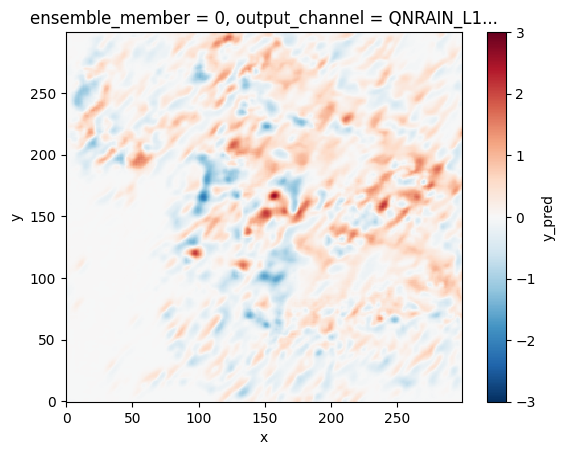

In [76]:
ds_norm['y_pred'].sel(output_channel='QNRAIN_L1').isel(sample=3).plot(vmin=-3, vmax=3, cmap='RdBu_r')

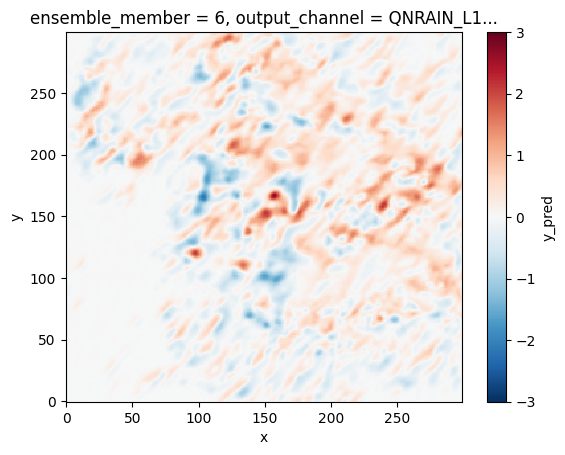

In [78]:
ds_norm['y_pred'].sel(output_channel='QNRAIN_L1').isel(sample=3).plot(vmin=-3, vmax=3, cmap='RdBu_r')

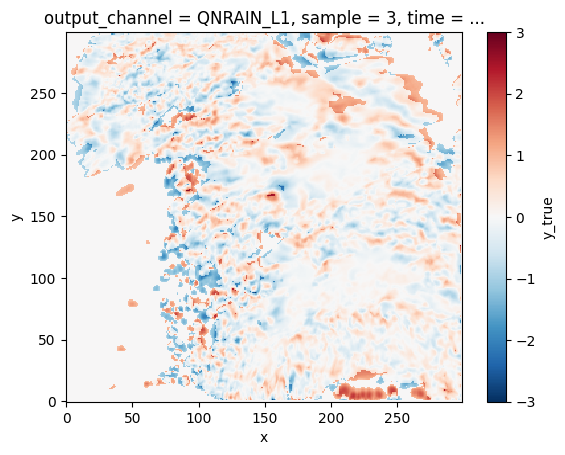

In [63]:
ds_norm['y_true'].sel(output_channel='QNRAIN_L1').isel(sample=3).plot(vmin=-3, vmax=3,cmap='RdBu_r')

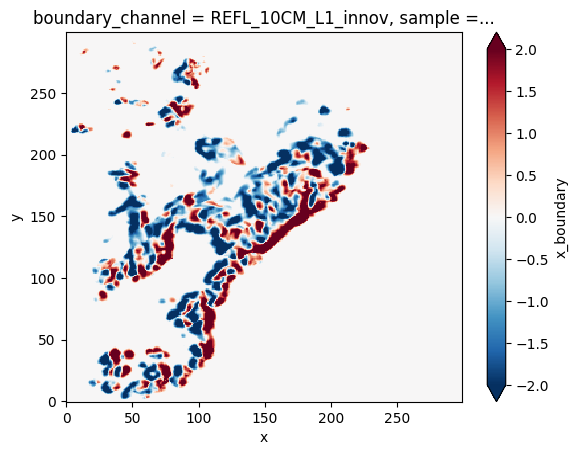

In [48]:
ds_norm.sel(boundary_channel='REFL_10CM_L1_innov')['x_boundary'].isel(sample=0).plot(vmin=-2, vmax=2,cmap='RdBu_r')

## denormalized

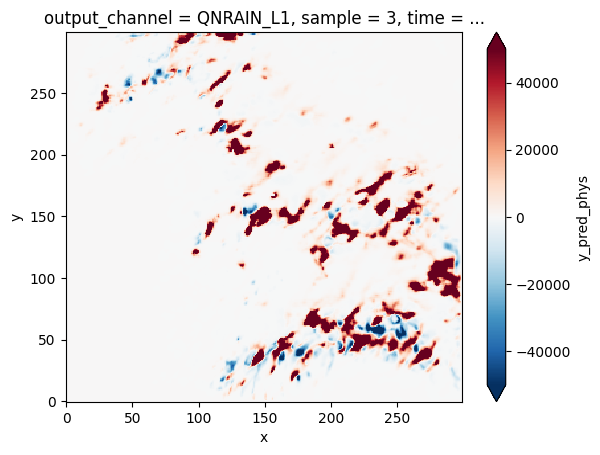

In [58]:
ds_denorm['y_pred_phys'].sel(output_channel='QNRAIN_L1').isel(sample=3).plot(cmap='RdBu_r',vmin=-5e4, vmax=5e4)

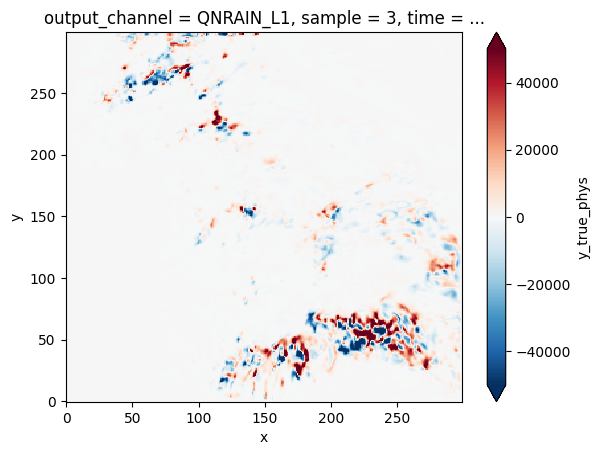

In [59]:
ds_denorm['y_true_phys'].sel(output_channel='QNRAIN_L1').isel(sample=3).plot(cmap='RdBu_r',vmin=-5e4, vmax=5e4)